In [4]:
# Cell 1 - Install
%pip install chembl_webresource_client fair-esm requests tqdm
%pip install rdkit-pypi

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [4]:
# Cell 2 - Imports
import pandas as pd
import torch
import numpy as np
import requests
from tqdm import tqdm

from pathlib import Path
import json
import pickle
import time

from chembl_webresource_client.new_client import new_client
from rdkit import Chem
from rdkit.Chem.inchi import MolToInchi, MolToInchiKey
import esm

# --- checkpointing helpers ---
ARTIFACTS_DIR = Path("./artifacts")
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)


def _atomic_write_bytes(path: Path, data: bytes) -> None:
    tmp = path.with_suffix(path.suffix + ".tmp")
    tmp.write_bytes(data)
    tmp.replace(path)


def save_json(obj, path: Path) -> None:
    _atomic_write_bytes(path, json.dumps(obj, indent=2, sort_keys=True).encode("utf-8"))


def save_pickle(obj, path: Path) -> None:
    _atomic_write_bytes(path, pickle.dumps(obj, protocol=pickle.HIGHEST_PROTOCOL))


def save_torch(obj, path: Path) -> None:
    # torch.save writes to path; we keep it simple + then add a small metadata json.
    torch.save(obj, path)


def save_df(df: pd.DataFrame, path: Path) -> None:
    # Prefer parquet if available; fallback to csv.
    try:
        df.to_parquet(path.with_suffix(".parquet"), index=False)
    except Exception:
        df.to_csv(path.with_suffix(".csv"), index=False)


def save_step(name: str, **objects) -> None:
    """Save intermediate data after each step.

    - DataFrames: parquet/csv
    - dict/list/etc: pickle + (optionally json when safe)
    """
    step_dir = ARTIFACTS_DIR / name
    step_dir.mkdir(parents=True, exist_ok=True)

    meta = {
        "saved_at": time.strftime("%Y-%m-%d %H:%M:%S"),
        "keys": sorted(objects.keys()),
    }

    for k, v in objects.items():
        if isinstance(v, pd.DataFrame):
            save_df(v, step_dir / k)
        else:
            save_pickle(v, step_dir / f"{k}.pkl")
            # best-effort json for small/simple objects
            try:
                if isinstance(v, (dict, list, str, int, float, bool)):
                    save_json(v, step_dir / f"{k}.json")
            except Exception:
                pass

    save_json(meta, step_dir / "_meta.json")
    print(f"Saved step '{name}' -> {step_dir}")

In [10]:
# Cell 3 - Load data
CSV_PATH = "final_processed_data.csv"
df = pd.read_csv(CSV_PATH)
print("Columns:", df.columns.tolist())
print(df.head(2))

# Get unique SMILES
smiles_set = set(df["SMILES1"]).union(set(df["SMILES2"]))
smiles_list = [s for s in smiles_set if isinstance(s, str) and len(s) > 0]
print("Total unique SMILES:", len(smiles_list))

save_step(
    "03_load_data",
    df=df,
    smiles_list=smiles_list,
    csv_path=CSV_PATH,
)

Columns: ['SMILES1', 'SMILES2', 'Side Effect Name']
                                             SMILES1  \
0  B(C(CC(C)C)NC(=O)C(CC1=CC=CC=C1)NC(=O)C2=NC=CN...   
1  B(C(CC(C)C)NC(=O)C(CC1=CC=CC=C1)NC(=O)C2=NC=CN...   

                                          SMILES2  \
0                              C(=O)(O)[O-].[Na+]   
1  C(C(CO[N+](=O)[O-])O[N+](=O)[O-])O[N+](=O)[O-]   

                                    Side Effect Name  
0  ['body temperature increased', 'Blood Calcium ...  
1  ['Adenopathy', 'Back Ache', 'narcolepsy', 'bod...  
Total unique SMILES: 644
Saved step '03_load_data' -> artifacts\03_load_data


In [7]:
# Cell 4 - Compute InChIKey locally with RDKit (reliable)
# This replaces the PubChem conversion step (which was failing and producing 0 downstream matches).

def smiles_to_inchikey_rdkit(smi: str) -> str | None:
    try:
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            return None
        return MolToInchiKey(mol)
    except Exception:
        return None

# Quick test
test_smi = smiles_list[0]
print("Testing RDKit InChIKey with:", test_smi[:60])
ik = smiles_to_inchikey_rdkit(test_smi)
print("InChIKey:", ik)

save_step(
    "04_inchikey_fn",
    test_smiles=test_smi,
    test_inchikey=ik,
)

Testing RDKit InChIKey with: CC12CCC3C(C1CCC2O)CCC4=C3C=CC(=C4)O
InChIKey: VOXZDWNPVJITMN-UHFFFAOYSA-N
Saved step '04_inchikey_fn' -> artifacts\04_inchikey_fn


In [8]:
# Cell 5 - Build SMILES -> ChEMBL ID via InChIKey (batched)
# This creates `smiles_to_chembl`, which is required for all later cells.

molecule_client = new_client.molecule

smiles_to_inchikey = {}
smiles_to_chembl = {}
failed_inchikey = []
failed_chembl = []

for smi in tqdm(smiles_list, desc="SMILES -> ChEMBL"):
    ik = smiles_to_inchikey_rdkit(smi)
    if not ik:
        failed_inchikey.append(smi)
        continue

    smiles_to_inchikey[smi] = ik

    try:
        chembl_id = None

        # 1) Query by standard InChIKey (best when available)
        res = molecule_client.filter(molecule_structures__standard_inchi_key=ik)
        for r in res:
            chembl_id = r.get("molecule_chembl_id")
            if chembl_id:
                break

        # 2) Fallback: query by canonical SMILES (sometimes ChEMBL doesn't store standard_inchi_key)
        if not chembl_id:
            res2 = molecule_client.filter(molecule_structures__canonical_smiles=smi)
            for r in res2:
                chembl_id = r.get("molecule_chembl_id")
                if chembl_id:
                    break

        if chembl_id:
            smiles_to_chembl[smi] = chembl_id
        else:
            failed_chembl.append(smi)
    except Exception:
        failed_chembl.append(smi)

    # Be polite to the API
    time.sleep(0.1)

print(f"InChIKey ok: {len(smiles_to_inchikey)} / {len(smiles_list)}")
print(f"ChEMBL mapped: {len(smiles_to_chembl)} / {len(smiles_list)}")
print(f"Failed InChIKey: {len(failed_inchikey)} | Failed ChEMBL lookup: {len(failed_chembl)}")

save_step(
    "05_smiles_to_chembl",
    smiles_to_inchikey=smiles_to_inchikey,
    smiles_to_chembl=smiles_to_chembl,
    failed_inchikey=failed_inchikey,
    failed_chembl=failed_chembl,
)

SMILES -> ChEMBL: 100%|██████████| 644/644 [01:10<00:00,  9.15it/s]

InChIKey ok: 644 / 644
ChEMBL mapped: 473 / 644
Failed InChIKey: 0 | Failed ChEMBL lookup: 171
Saved step '05_smiles_to_chembl' -> artifacts\05_smiles_to_chembl


In [9]:
# Cell 6 - Get targets for each ChEMBL drug
activity = new_client.activity

chembl_to_targets = {}

unique_chembl_ids = list(set(smiles_to_chembl.values()))
print(f"Unique ChEMBL IDs to query: {len(unique_chembl_ids)}")

for chembl_id in tqdm(unique_chembl_ids):
    try:
        res = activity.filter(
            molecule_chembl_id=chembl_id,
            target_organism="Homo sapiens",
        )
        targets = list(
            set(r["target_chembl_id"] for r in res if r.get("target_chembl_id"))
        )
        if targets:
            chembl_to_targets[chembl_id] = targets
    except Exception:
        continue

print(f"Drugs with targets: {len(chembl_to_targets)}")

save_step(
    "06_chembl_targets",
    unique_chembl_ids=unique_chembl_ids,
    chembl_to_targets=chembl_to_targets,
)

Unique ChEMBL IDs to query: 473


100%|██████████| 473/473 [06:11<00:00,  1.27it/s] 

Drugs with targets: 406
Saved step '06_chembl_targets' -> artifacts\06_chembl_targets


In [10]:
# Cell 7 - Get UniProt accessions (only run AFTER cell 6)
target_client = new_client.target

target_to_uniprot = {}

for chembl_id, targets in tqdm(chembl_to_targets.items()):
    uniprots = []
    for t in targets:
        try:
            res = target_client.get(t)
            if res is None:
                continue
            comps = res.get("target_components", [])
            for c in comps:
                acc = c.get("accession")
                if acc:
                    uniprots.append(acc)
        except Exception:
            continue
    if uniprots:
        target_to_uniprot[chembl_id] = list(set(uniprots))

print(f"ChEMBL IDs with UniProt mappings: {len(target_to_uniprot)}")
print(f"Total UniProt IDs to fetch: {sum(len(v) for v in target_to_uniprot.values())}")

save_step(
    "07_uniprot_accessions",
    target_to_uniprot=target_to_uniprot,
)

100%|██████████| 406/406 [38:11<00:00,  5.64s/it]   

ChEMBL IDs with UniProt mappings: 399
Total UniProt IDs to fetch: 36946
Saved step '07_uniprot_accessions' -> artifacts\07_uniprot_accessions


In [11]:
# Cell 8 - Fetch protein sequences from UniProt
def fetch_sequence(uniprot_id):
    try:
        url = f"https://rest.uniprot.org/uniprotkb/{uniprot_id}.fasta"
        r = requests.get(url, timeout=10)
        if r.status_code == 200:
            lines = r.text.strip().split("\n")
            return "".join(lines[1:])  # skip header line
    except Exception:
        return None

# Collect all unique UniProt IDs
all_uniprot_ids = set()
for prots in target_to_uniprot.values():
    all_uniprot_ids.update(prots)

print(f"Unique UniProt IDs: {len(all_uniprot_ids)}")

uniprot_to_seq = {}

for uniprot_id in tqdm(all_uniprot_ids):
    seq = fetch_sequence(uniprot_id)
    if seq:
        uniprot_to_seq[uniprot_id] = seq

print(f"Sequences fetched: {len(uniprot_to_seq)} / {len(all_uniprot_ids)}")

save_step(
    "08_uniprot_sequences",
    all_uniprot_ids=sorted(all_uniprot_ids),
    uniprot_to_seq=uniprot_to_seq,
)

Unique UniProt IDs: 1444


100%|██████████| 1444/1444 [18:00<00:00,  1.34it/s]

Sequences fetched: 1443 / 1444
Saved step '08_uniprot_sequences' -> artifacts\08_uniprot_sequences


In [12]:
# Cell 9 - Load ESM2 model (650M)
# Requested: esm650million
model, alphabet = esm.pretrained.esm2_t33_650M_UR50D()
batch_converter = alphabet.get_batch_converter()
model.eval()

# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
print(f"Using device: {device}")

save_step(
    "09_esm_model",
    esm_model_name="esm2_t33_650M_UR50D",
    device=str(device),
)

Downloading: "https://dl.fbaipublicfiles.com/fair-esm/models/esm2_t33_650M_UR50D.pt" to C:\Users\mg276/.cache\torch\hub\checkpoints\esm2_t33_650M_UR50D.pt
Downloading: "https://dl.fbaipublicfiles.com/fair-esm/regression/esm2_t33_650M_UR50D-contact-regression.pt" to C:\Users\mg276/.cache\torch\hub\checkpoints\esm2_t33_650M_UR50D-contact-regression.pt


Using device: cuda
Saved step '09_esm_model' -> artifacts\09_esm_model


In [13]:
# Cell 10 - Define embedding function
MAX_SEQ_LEN = 1022  # ESM2 max is 1024 tokens including special tokens
ESM_REPR_LAYER = 33  # for esm2_t33_650M_UR50D

def get_protein_embedding(sequence: str) -> torch.Tensor:
    sequence = sequence[:MAX_SEQ_LEN]  # truncate if too long
    data = [("protein", sequence)]
    _, _, tokens = batch_converter(data)
    tokens = tokens.to(device)

    with torch.no_grad():
        results = model(tokens, repr_layers=[ESM_REPR_LAYER], return_contacts=False)

    emb = results["representations"][ESM_REPR_LAYER]
    return emb[0, 1:-1].mean(0).cpu()  # mean pooling, move back to CPU

save_step(
    "10_embedding_fn",
    max_seq_len=MAX_SEQ_LEN,
    esm_repr_layer=ESM_REPR_LAYER,
)

Saved step '10_embedding_fn' -> artifacts\10_embedding_fn


In [5]:
# Cell 11 - Generate drug-protein embeddings
drug_protein_emb = {}  # original SMILES → mean protein embedding

for smi, chembl_id in tqdm(smiles_to_chembl.items()):
    if chembl_id not in target_to_uniprot:
        continue

    prots = target_to_uniprot[chembl_id]
    embs = []

    for p in prots:
        if p in uniprot_to_seq:
            try:
                emb = get_protein_embedding(uniprot_to_seq[p])
                embs.append(emb)
            except Exception as e:
                print(f"Failed on {p}: {e}")
                continue

    if embs:
        drug_protein_emb[smi] = torch.stack(embs).mean(dim=0)

print(f"Drugs with protein embeddings: {len(drug_protein_emb)} / {len(smiles_to_chembl)}")

# Save immediately in the same cell
out_path = Path("drug_protein_embeddings.pt")
save_torch(drug_protein_emb, out_path)

save_step(
    "11_drug_protein_embeddings",
    n_embeddings=len(drug_protein_emb),
    output_file=str(out_path),
)

NameError: name 'smiles_to_chembl' is not defined

In [ ]:
# # Cell 1b - Sanity check (NumPy + RDKit)
# import sys

# print("Kernel Python:", sys.executable)

# import numpy as np
# print("NumPy:", np.__version__)

# try:
#     from rdkit import Chem
#     from rdkit.Chem import AllChem
# except Exception as e:
#     print("RDKit import FAILED:", repr(e))
#     raise

# print("RDKit import OK")

Kernel Python: c:\Users\mg276\AppData\Local\Programs\Python\Python311\python.exe
NumPy: 1.26.4
RDKit import OK


In [11]:
# Cell 12a - Impute missing protein embeddings via ECFP4 (Tanimoto) lookup
# Strategy: for drugs without protein embeddings, borrow a weighted average from top-k most similar mapped drugs.

from rdkit.Chem import AllChem
from rdkit import DataStructs

K_NEIGHBORS = 3
FP_RADIUS = 2  # ECFP4
FP_NBITS = 2048
MIN_TANIMOTO = 0.25  # avoid very weak proxies

import torch
from pathlib import Path

in_path = Path("drug_protein_embeddings.pt")

drug_protein_emb = torch.load(in_path)


def _safe_mol_from_smiles(smi: str):
    try:
        return Chem.MolFromSmiles(smi)
    except Exception:
        return None


def _ecfp4_fp(smi: str):
    mol = _safe_mol_from_smiles(smi)
    if mol is None:
        return None
    try:
        return AllChem.GetMorganFingerprintAsBitVect(mol, radius=FP_RADIUS, nBits=FP_NBITS)
    except Exception:
        return None


mapped_smiles = [s for s in smiles_list if s in drug_protein_emb]
missing_smiles = [s for s in smiles_list if s not in drug_protein_emb]

print(f"Mapped embeddings: {len(mapped_smiles)} | Missing embeddings: {len(missing_smiles)}")

if len(mapped_smiles) == 0:
    print("No mapped embeddings available; skipping similarity imputation.")
else:
    # Precompute fingerprints
    fp_cache = {}
    for smi in mapped_smiles:
        fp_cache[smi] = _ecfp4_fp(smi)

    # Keep only valid mapped fps
    mapped_smiles_valid = [s for s in mapped_smiles if fp_cache.get(s) is not None]
    mapped_fps_valid = [fp_cache[s] for s in mapped_smiles_valid]

    imputed = 0
    skipped = 0

    for smi in tqdm(missing_smiles, desc="Imputing via Tanimoto"):
        fp_u = _ecfp4_fp(smi)
        if fp_u is None:
            skipped += 1
            continue

        sims = DataStructs.BulkTanimotoSimilarity(fp_u, mapped_fps_valid)
        # pick top-k
        idxs = np.argsort(sims)[::-1][:K_NEIGHBORS]
        top = [(mapped_smiles_valid[i], float(sims[i])) for i in idxs if sims[i] >= MIN_TANIMOTO]

        if not top:
            skipped += 1
            continue

        # weighted mean of neighbor embeddings
        weights = torch.tensor([w for _, w in top], dtype=torch.float32)
        weights = weights / weights.sum()
        embs = torch.stack([drug_protein_emb[ms] for ms, _ in top])
        drug_protein_emb[smi] = (embs * weights[:, None]).sum(dim=0)
        imputed += 1

    print(f"Imputed: {imputed} | Skipped: {skipped}")

    # Save updated embeddings
    out_path = Path("drug_protein_embeddings_imputed.pt")
    save_torch(drug_protein_emb, out_path)

    save_step(
        "12a_similarity_imputation",
        k_neighbors=K_NEIGHBORS,
        fp_radius=FP_RADIUS,
        fp_nbits=FP_NBITS,
        min_tanimoto=MIN_TANIMOTO,
        imputed=imputed,
        skipped=skipped,
        output_file=str(out_path),
        n_total=len(drug_protein_emb),
    )

C:\Users\mg276\AppData\Local\Temp\ipykernel_18840\2440297585.py:17: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  drug_protein_emb = torch.load(in_path)


Mapped embeddings: 399 | Missing embeddings: 245


Imputing via Tanimoto: 100%|██████████| 245/245 [00:00<00:00, 3765.82it/s]

Imputed: 148 | Skipped: 97
Saved step '12a_similarity_imputation' -> artifacts\12a_similarity_imputation


In [12]:
# Cell 12 - Verify saved file
# Prefer the imputed file if it exists.
path_candidates = [
    "drug_protein_embeddings_imputed.pt",
    "drug_protein_embeddings.pt",
]

chosen = next((p for p in path_candidates if Path(p).exists()), path_candidates[-1])
loaded = torch.load(chosen, weights_only=False)
print(f"Loaded: {chosen} | embeddings: {len(loaded)}")

# Check embedding shape
for smi, emb in list(loaded.items())[:3]:
    print(f"  SMILES: {smi[:40]}... | Embedding shape: {emb.shape}")

save_step(
    "12_verify_embeddings",
    file=chosen,
    n_loaded=len(loaded),
    sample_keys=[k for k in list(loaded.keys())[:10]],
)

Loaded: drug_protein_embeddings_imputed.pt | embeddings: 547
  SMILES: CC12CCC3C(C1CCC2O)CCC4=C3C=CC(=C4)O... | Embedding shape: torch.Size([1280])
  SMILES: CCCC(C)(COC(=O)N)COC(=O)N... | Embedding shape: torch.Size([1280])
  SMILES: C1=CN=C(C=N1)C(=O)N... | Embedding shape: torch.Size([1280])
Saved step '12_verify_embeddings' -> artifacts\12_verify_embeddings


In [16]:
import pickle

with open("./artifacts/05_smiles_to_chembl/smiles_to_chembl.pkl", "rb") as f:
    smiles_to_chembl = pickle.load(f)

print(type(smiles_to_chembl))
print(len(smiles_to_chembl))

<class 'dict'>
473


In [17]:
# Cell 13 - Retry ChEMBL mapping for failed drugs using largest organic fragment
# Run this AFTER Cell 5.

from rdkit.Chem import rdmolops


def largest_organic_fragment_smiles(smi: str) -> str | None:
    """Return SMILES of the largest organic fragment (prefers fragments with carbon)."""
    try:
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            return None

        frags = Chem.GetMolFrags(mol, asMols=True, sanitizeFrags=False)
        if not frags:
            return None

        def frag_score(m):
            heavy = m.GetNumHeavyAtoms()
            has_c = any(a.GetAtomicNum() == 6 for a in m.GetAtoms())
            return (1 if has_c else 0, heavy)

        best = max(frags, key=frag_score)
        Chem.SanitizeMol(best)
        return Chem.MolToSmiles(best, canonical=True)
    except Exception:
        return None


# Work on only the previously failed ChEMBL lookups
failed = list(failed_chembl) if "failed_chembl" in globals() else []
print("Failed before retry:", len(failed))

recovered = 0
still_failed = []

for smi in tqdm(failed, desc="Retry largest fragment"):
    cleaned = largest_organic_fragment_smiles(smi)
    if not cleaned or cleaned == smi:
        cleaned = cleaned or smi

    ik2 = smiles_to_inchikey_rdkit(cleaned)
    if not ik2:
        still_failed.append(smi)
        continue

    try:
        chembl_id = None

        res = molecule_client.filter(molecule_structures__standard_inchi_key=ik2)
        for r in res:
            chembl_id = r.get("molecule_chembl_id")
            if chembl_id:
                break

        if not chembl_id:
            res2 = molecule_client.filter(molecule_structures__canonical_smiles=cleaned)
            for r in res2:
                chembl_id = r.get("molecule_chembl_id")
                if chembl_id:
                    break

        if chembl_id:
            smiles_to_chembl[smi] = chembl_id
            smiles_to_inchikey[smi] = ik2
            recovered += 1
        else:
            still_failed.append(smi)
    except Exception:
        still_failed.append(smi)

print("Recovered by largest-fragment retry:", recovered)
print("Still failed:", len(still_failed))
print("Total mapped now:", len(smiles_to_chembl), "/", len(smiles_list))

save_step(
    "13_retry_largest_fragment",
    recovered=recovered,
    still_failed=still_failed,
    smiles_to_chembl=smiles_to_chembl,
)

Failed before retry: 0


Retry largest fragment: 0it [00:00, ?it/s]

Recovered by largest-fragment retry: 0
Still failed: 0
Total mapped now: 473 / 644
Saved step '13_retry_largest_fragment' -> artifacts\13_retry_largest_fragment


In [18]:
# Cell 14 - PubChem fallback (leftovers only): SMILES -> CID -> Assay targets -> GeneID -> UniProt -> ESM embedding
# Run this AFTER you have:
# - still_failed (from Cell 13)
# - ESM model loaded (Cells 9-10)
# - get_protein_embedding defined (Cell 10)
# - drug_protein_emb dict created (Cell 11)

import urllib.parse
from collections import defaultdict


def pubchem_smiles_to_cid(smi: str) -> int | None:
    try:
        encoded = urllib.parse.quote(smi, safe="")
        url = f"https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/smiles/{encoded}/cids/JSON"
        r = requests.get(url, timeout=20)
        if r.status_code != 200:
            return None
        data = r.json()
        cids = data.get("IdentifierList", {}).get("CID", [])
        return int(cids[0]) if cids else None
    except Exception:
        return None


def pubchem_cid_to_aids(cid: int, max_aids: int = 30) -> list[int]:
    """Return a list of assay IDs (AIDs) associated with a compound."""
    try:
        url = f"https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/cid/{cid}/assaysummary/JSON"
        r = requests.get(url, timeout=30)
        if r.status_code != 200:
            return []
        data = r.json()
        summaries = data.get("AssaySummaries", [])
        aids = []
        for s in summaries:
            aid = s.get("AID")
            if aid is not None:
                aids.append(int(aid))
            if len(aids) >= max_aids:
                break
        return aids
    except Exception:
        return []


def pubchem_aid_to_geneids(aid: int) -> list[int]:
    """Fetch GeneIDs for an assay target."""
    try:
        url = f"https://pubchem.ncbi.nlm.nih.gov/rest/pug/assay/aid/{aid}/targets/GeneID/JSON"
        r = requests.get(url, timeout=30)
        if r.status_code != 200:
            return []
        data = r.json()
        # structure: {"InformationList": {"Information": [{"GeneID": [..]}]}}
        infos = data.get("InformationList", {}).get("Information", [])
        gene_ids: list[int] = []
        for info in infos:
            for gid in info.get("GeneID", []) if isinstance(info.get("GeneID"), list) else [info.get("GeneID")]:
                if gid is None:
                    continue
                try:
                    gene_ids.append(int(gid))
                except Exception:
                    continue
        return list(sorted(set(gene_ids)))
    except Exception:
        return []


def geneid_to_uniprot(gene_id: int) -> str | None:
    """Map NCBI GeneID -> UniProt accession (human)."""
    try:
        url = (
            "https://rest.uniprot.org/uniprotkb/search"
            f"?query=gene_exact:{gene_id}+AND+organism_id:9606&format=json&size=1"
        )
        r = requests.get(url, timeout=20)
        if r.status_code != 200:
            return None
        js = r.json()
        results = js.get("results", [])
        if not results:
            return None
        return results[0].get("primaryAccession")
    except Exception:
        return None


def uniprot_to_sequence(acc: str) -> str | None:
    try:
        url = f"https://rest.uniprot.org/uniprotkb/{acc}.fasta"
        r = requests.get(url, timeout=20)
        if r.status_code != 200:
            return None
        lines = r.text.strip().split("\n")
        return "".join(lines[1:]) if len(lines) > 1 else None
    except Exception:
        return None


leftovers = list(still_failed) if "still_failed" in globals() else []
print("Leftovers to try via PubChem:", len(leftovers))

# caches
_gene2uni: dict[int, str | None] = {}
_uni2seq: dict[str, str | None] = {}
_uni2emb: dict[str, torch.Tensor] = {}

recovered_pubchem = 0

for smi in tqdm(leftovers, desc="PubChem fallback"):
    cid = pubchem_smiles_to_cid(smi)
    if cid is None:
        continue

    aids = pubchem_cid_to_aids(cid, max_aids=20)
    if not aids:
        continue

    gene_ids: set[int] = set()
    for aid in aids[:20]:
        for gid in pubchem_aid_to_geneids(aid):
            gene_ids.add(gid)
        # keep this bounded
        if len(gene_ids) >= 10:
            break

    if not gene_ids:
        continue

    # map geneids -> uniprot
    uniprots: list[str] = []
    for gid in list(gene_ids)[:10]:
        if gid not in _gene2uni:
            _gene2uni[gid] = geneid_to_uniprot(gid)
        acc = _gene2uni[gid]
        if acc:
            uniprots.append(acc)

    uniprots = list(dict.fromkeys(uniprots))  # preserve order, unique
    if not uniprots:
        continue

    # fetch sequences + embed with ESM
    prot_embs = []
    for acc in uniprots[:5]:
        if acc not in _uni2seq:
            _uni2seq[acc] = uniprot_to_sequence(acc)
        seq = _uni2seq[acc]
        if not seq or len(seq) < 10:
            continue

        if acc not in _uni2emb:
            try:
                _uni2emb[acc] = get_protein_embedding(seq)
            except Exception:
                continue

        prot_embs.append(_uni2emb[acc])

    if not prot_embs:
        continue

    # mean pool proteins -> drug embedding
    drug_vec = torch.stack(prot_embs).mean(dim=0)
    drug_protein_emb[smi] = drug_vec
    recovered_pubchem += 1

print("Recovered via PubChem fallback:", recovered_pubchem)
print("Total drug_protein_emb now:", len(drug_protein_emb))

# Save updated embeddings
out_path = Path("drug_protein_embeddings.pt")
save_torch(drug_protein_emb, out_path)
print("Saved updated:", out_path)

save_step(
    "14_pubchem_fallback",
    recovered_pubchem=recovered_pubchem,
    output_file=str(out_path),
    n_embeddings=len(drug_protein_emb),
)

Leftovers to try via PubChem: 0


PubChem fallback: 0it [00:00, ?it/s]

Recovered via PubChem fallback: 0
Total drug_protein_emb now: 547
Saved updated: drug_protein_embeddings.pt
Saved step '14_pubchem_fallback' -> artifacts\14_pubchem_fallback


In [19]:
#no labels on the drug protein embeddings just to note
import pickle
import numpy as np

file_path = "drug_protein_embeddings.pt"

data=torch.load(file_path)

print("Type of loaded object:", type(data))

# # Convert dict → matrix
embeddings = np.array(list(data.values()))
# keys = list(data.keys())

# print("Shape:", embeddings.shape)   # (N, 1024)
# print("NaNs:", np.isnan(embeddings).sum())
# print("Infs:", np.isinf(embeddings).sum())

# norms = np.linalg.norm(embeddings, axis=1)

# print("Min norm:", norms.min())
# print("Max norm:", norms.max())
# print("Mean norm:", norms.mean())

# variance = np.var(embeddings, axis=0)

# print("Mean variance across dimensions:", variance.mean())
# print("Zero-variance dims:", np.sum(variance == 0))

Type of loaded object: <class 'dict'>


C:\Users\mg276\AppData\Local\Temp\ipykernel_18840\3085677244.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data=torch.load(file_path)


Shape: (547, 1280)

--- Norm Stats ---
Mean norm: 6.0997424
Std norm: 0.6834594
Min norm: 4.908361
Max norm: 9.29512

--- Zero Vector Check ---
Zero embeddings: 0
Percentage: 0.0

--- Cosine Similarity ---
Mean: 0.97428924
Std: 0.0340196
Min: 0.54221964
Max: 1.0000006

--- Uniqueness ---
Unique embeddings: 506
Total embeddings: 547


C:\Users\mg276\AppData\Local\Temp\ipykernel_18840\3634497142.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  emb_dict=torch.load("drug_protein_embeddings.pt")


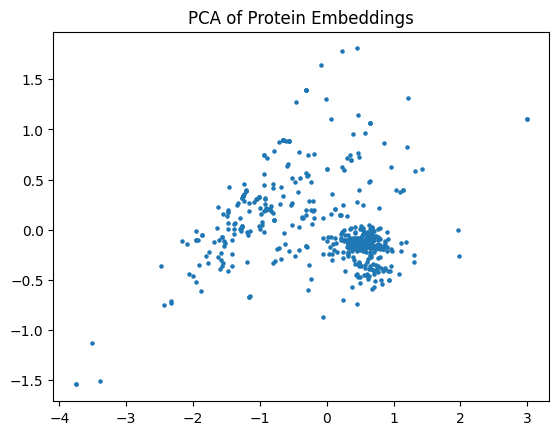

In [21]:
import pickle
import numpy as np
import torch
import torch.nn.functional as F
from sklearn.metrics.pairwise import cosine_similarity

# =========================
# LOAD EMBEDDINGS
# =========================
emb_dict=torch.load("drug_protein_embeddings.pt")

embs = np.stack(list(emb_dict.values()))   # shape (N, 1024)

print("Shape:", embs.shape)

# =========================
# 1. NORM STATS
# =========================
norms = np.linalg.norm(embs, axis=1)

print("\n--- Norm Stats ---")
print("Mean norm:", norms.mean())
print("Std norm:", norms.std())
print("Min norm:", norms.min())
print("Max norm:", norms.max())

# =========================
# 2. ZERO VECTOR CHECK (CRITICAL)
# =========================
zero_mask = norms == 0
num_zero = np.sum(zero_mask)

print("\n--- Zero Vector Check ---")
print("Zero embeddings:", num_zero)
print("Percentage:", num_zero / len(embs))

# =========================
# 3. COSINE SIMILARITY (sampled)
# =========================
idx = np.random.choice(len(embs), size=min(500, len(embs)), replace=False)
sample = embs[idx]

sample = sample / (np.linalg.norm(sample, axis=1, keepdims=True) + 1e-8)
sims = sample @ sample.T

upper = sims[np.triu_indices_from(sims, k=1)]

print("\n--- Cosine Similarity ---")
print("Mean:", upper.mean())
print("Std:", upper.std())
print("Min:", upper.min())
print("Max:", upper.max())

# =========================
# 4. DUPLICATE CHECK
# =========================
unique_rows = np.unique(embs, axis=0)

print("\n--- Uniqueness ---")
print("Unique embeddings:", len(unique_rows))
print("Total embeddings:", len(embs))

# =========================
# 5. OPTIONAL PCA VISUALIZATION
# =========================
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

X = embs[:1000]  # sample

pca = PCA(n_components=2)
X_2d = pca.fit_transform(X)

plt.scatter(X_2d[:,0], X_2d[:,1], s=5)
plt.title("PCA of Protein Embeddings")
plt.show()

In [24]:
import numpy as np
import torch
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import NearestNeighbors

def _coerce_embeddings(embeddings):
    # Returns: X (N,D float32), keys (or None)
    if isinstance(embeddings, dict):
        keys = list(embeddings.keys())
        vals = []
        for k in keys:
            v = embeddings[k]
            if isinstance(v, torch.Tensor):
                v = v.detach().cpu().float().reshape(-1).numpy()
            else:
                v = np.asarray(v, dtype=np.float32).reshape(-1)
            vals.append(v)

        if len(vals) == 0:
            raise ValueError("Embedding dict is empty.")

        dims = {arr.shape[0] for arr in vals}
        if len(dims) != 1:
            raise ValueError(f"Inconsistent embedding dims in dict: {sorted(dims)}")

        X = np.stack(vals).astype(np.float32)
        return X, keys

    if isinstance(embeddings, torch.Tensor):
        X = embeddings.detach().cpu().numpy().astype(np.float32)
    else:
        X = np.asarray(embeddings, dtype=np.float32)

    if X.ndim == 1:
        X = X[None, :]
    if X.ndim != 2:
        raise ValueError(f"Expected 2D embeddings, got shape {X.shape}")

    return X, None


def strict_embedding_report(embeddings, labels=None, sample_pairs=20000, seed=42):
    X, keys = _coerce_embeddings(embeddings)
    N, D = X.shape

    norms = np.linalg.norm(X, axis=1)
    zero_mask = norms == 0
    Xn = X / np.clip(norms[:, None], 1e-12, None)

    Xr = np.round(X, 6)
    unique_count = np.unique(Xr, axis=0).shape[0]
    dup_count = N - unique_count

    rng = np.random.default_rng(seed)
    if N <= 3000:
        S = cosine_similarity(Xn)
        iu = np.triu_indices(N, k=1)  # excludes diagonal
        cos_vals = S[iu]
    else:
        i = rng.integers(0, N, size=sample_pairs)
        j = rng.integers(0, N, size=sample_pairs)
        m = i != j
        i, j = i[m], j[m]
        cos_vals = np.sum(Xn[i] * Xn[j], axis=1)

    report = {
        "shape": (N, D),
        "norm_mean": float(norms.mean()),
        "norm_std": float(norms.std()),
        "norm_min": float(norms.min()),
        "norm_max": float(norms.max()),
        "zero_embeddings": int(zero_mask.sum()),
        "zero_pct": float(100 * zero_mask.mean()),
        "cosine_offdiag_mean": float(cos_vals.mean()),
        "cosine_offdiag_std": float(cos_vals.std()),
        "cosine_offdiag_p5": float(np.percentile(cos_vals, 5)),
        "cosine_offdiag_p50": float(np.percentile(cos_vals, 50)),
        "cosine_offdiag_p95": float(np.percentile(cos_vals, 95)),
        "unique_embeddings": int(unique_count),
        "duplicate_embeddings": int(dup_count),
    }

    if labels is not None:
        y = np.asarray(labels)
        if len(y) != N:
            raise ValueError(f"labels length {len(y)} != N {N}")

        if N <= 3000:
            S = cosine_similarity(Xn)
            same = y[:, None] == y[None, :]
            offdiag = ~np.eye(N, dtype=bool)
            within = S[same & offdiag]
            between = S[(~same) & offdiag]
        else:
            i = rng.integers(0, N, size=sample_pairs)
            j = rng.integers(0, N, size=sample_pairs)
            m = i != j
            i, j = i[m], j[m]
            sim = np.sum(Xn[i] * Xn[j], axis=1)
            same = (y[i] == y[j])
            within = sim[same]
            between = sim[~same]

        report["within_class_cos_mean"] = float(within.mean()) if within.size else np.nan
        report["between_class_cos_mean"] = float(between.mean()) if between.size else np.nan
        report["separation_gap"] = (
            report["within_class_cos_mean"] - report["between_class_cos_mean"]
            if within.size and between.size else np.nan
        )

        nn = NearestNeighbors(n_neighbors=2, metric="cosine")
        nn.fit(Xn)
        _, idx = nn.kneighbors(Xn)
        nn1 = idx[:, 1]
        report["nn1_label_hit_rate"] = float((y[nn1] == y).mean())

    print("=== Strict Embedding Report ===")
    for k, v in report.items():
        print(f"{k}: {v}")

    if keys is not None:
        print(f"\nLoaded dict embeddings with {len(keys)} keys (first 5): {keys[:5]}")

    return report

In [25]:
embeddings = torch.load("drug_fused_embeddings.pt", map_location="cpu", weights_only=False)
rep = strict_embedding_report(embeddings)

=== Strict Embedding Report ===
shape: (644, 256)
norm_mean: 1.0
norm_std: 4.650291529628703e-08
norm_min: 0.9999998211860657
norm_max: 1.0000001192092896
zero_embeddings: 0
zero_pct: 0.0
cosine_offdiag_mean: -0.0007328272331506014
cosine_offdiag_std: 0.11997026205062866
cosine_offdiag_p5: -0.17457327991724014
cosine_offdiag_p50: -0.010576465167105198
cosine_offdiag_p95: 0.19950079172849655
unique_embeddings: 644
duplicate_embeddings: 0

Loaded dict embeddings with 644 keys (first 5): ['CC(C)NCC(C1=CC=C(C=C1)NS(=O)(=O)C)O', '[Li+].[AlH4-]', 'C=CCN.C1C(O1)CCl', 'C(C1C(C(C(C(O1)OC2(C(C(C(O2)OS(=O)(=O)O)OS(=O)(=O)O)OS(=O)(=O)O)COS(=O)(=O)O)OS(=O)(=O)O)OS(=O)(=O)O)OS(=O)(=O)O)OS(=O)(=O)O.O.O.O.O.O.O.O.O.O.O.O.O.O.O.O.O.O.O.O.O.[Al].[Al].[Al].[Al].[Al].[Al].[Al].[Al].[Al]', 'CC(C1C(O1)CC2COC(C(C2O)O)CC(=CC(=O)OCCCCCCCCC(=O)O)C)C(C)O']
